# consumer complaints

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = "/content/Consumer_Complaints.csv"

df = pd.read_csv(INPUT_PATH, parse_dates=["Date submitted", "Date received"])

print("Shape:", df.shape)
print(df.dtypes)
print(df.isna().sum())

Shape: (62516, 12)
Complaint ID                             int64
Submitted via                           object
Date submitted                  datetime64[ns]
Date received                   datetime64[ns]
State                                   object
Product                                 object
Sub-product                             object
Issue                                   object
Sub-issue                               object
Company public response                 object
Company response to consumer            object
Timely response?                        object
dtype: object
Complaint ID                        0
Submitted via                       0
Date submitted                      0
Date received                       0
State                               0
Product                             0
Sub-product                         7
Issue                               0
Sub-issue                       10858
Company public response          2175
Company response to con

## Do consumer complaints show any seasonal patterns?

In [7]:
df["Month"] = df["Date submitted"].dt.month_name()

month_order = [
"January", "February", "March", "April", "May", "June",
"July", "August", "September", "October", "November", "December",
]

seasonal = df["Month"].value_counts().reindex(month_order)
seasonal

,count
Month,
January,4883
February,4602
March,5335
April,5386
May,5608
June,5575
July,6474
August,5684
September,4765


In [8]:
df["Year"] = df["Date submitted"].dt.year
year = df["Year"].value_counts().sort_index()

year

,count
Year,
2017,5394
2018,7872
2019,7075
2020,8942
2021,11149
2022,12953
2023,9131


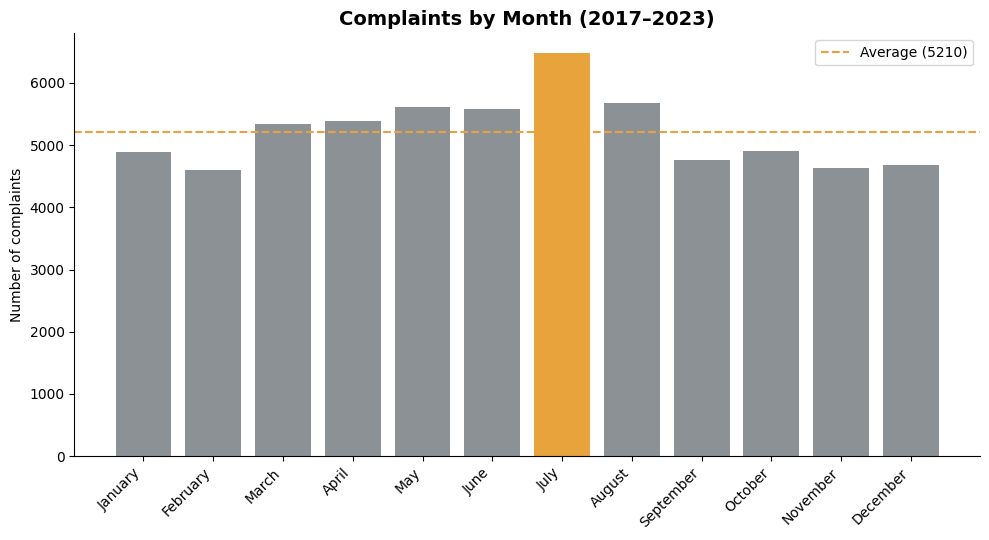

In [9]:
colors = {"gold": "#E8A33D", "grey": "#8C9196"}

max_val = seasonal.max()
bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in seasonal.values]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(month_order, seasonal.values, color=bar_colors)

avg = seasonal.mean()
ax.axhline(avg, color=colors["gold"], linestyle="--", linewidth=1.5, label=f"Average ({avg:.0f})")

ax.set_title("Complaints by Month (2017–2023)", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of complaints")
plt.xticks(rotation=45, ha="right")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
plt.close()

In [10]:
df = pd.read_csv('Consumer_Complaints.csv', parse_dates=['Date submitted'])
df['Year'] = df['Date submitted'].dt.year
df['Month'] = df['Date submitted'].dt.month

seasonality_df = df.groupby(by=["Year", "Month"]).agg({
    "Complaint ID": "count"
})
seasonality_df

Complaint ID
Year Month              
2017 5               744
     6               701
     7               701
     8               666
     9               635
...                  ...
2023 4              1058
     5              1085
     6              1018
     7              1749
     8               717

[76 rows x 1 columns]

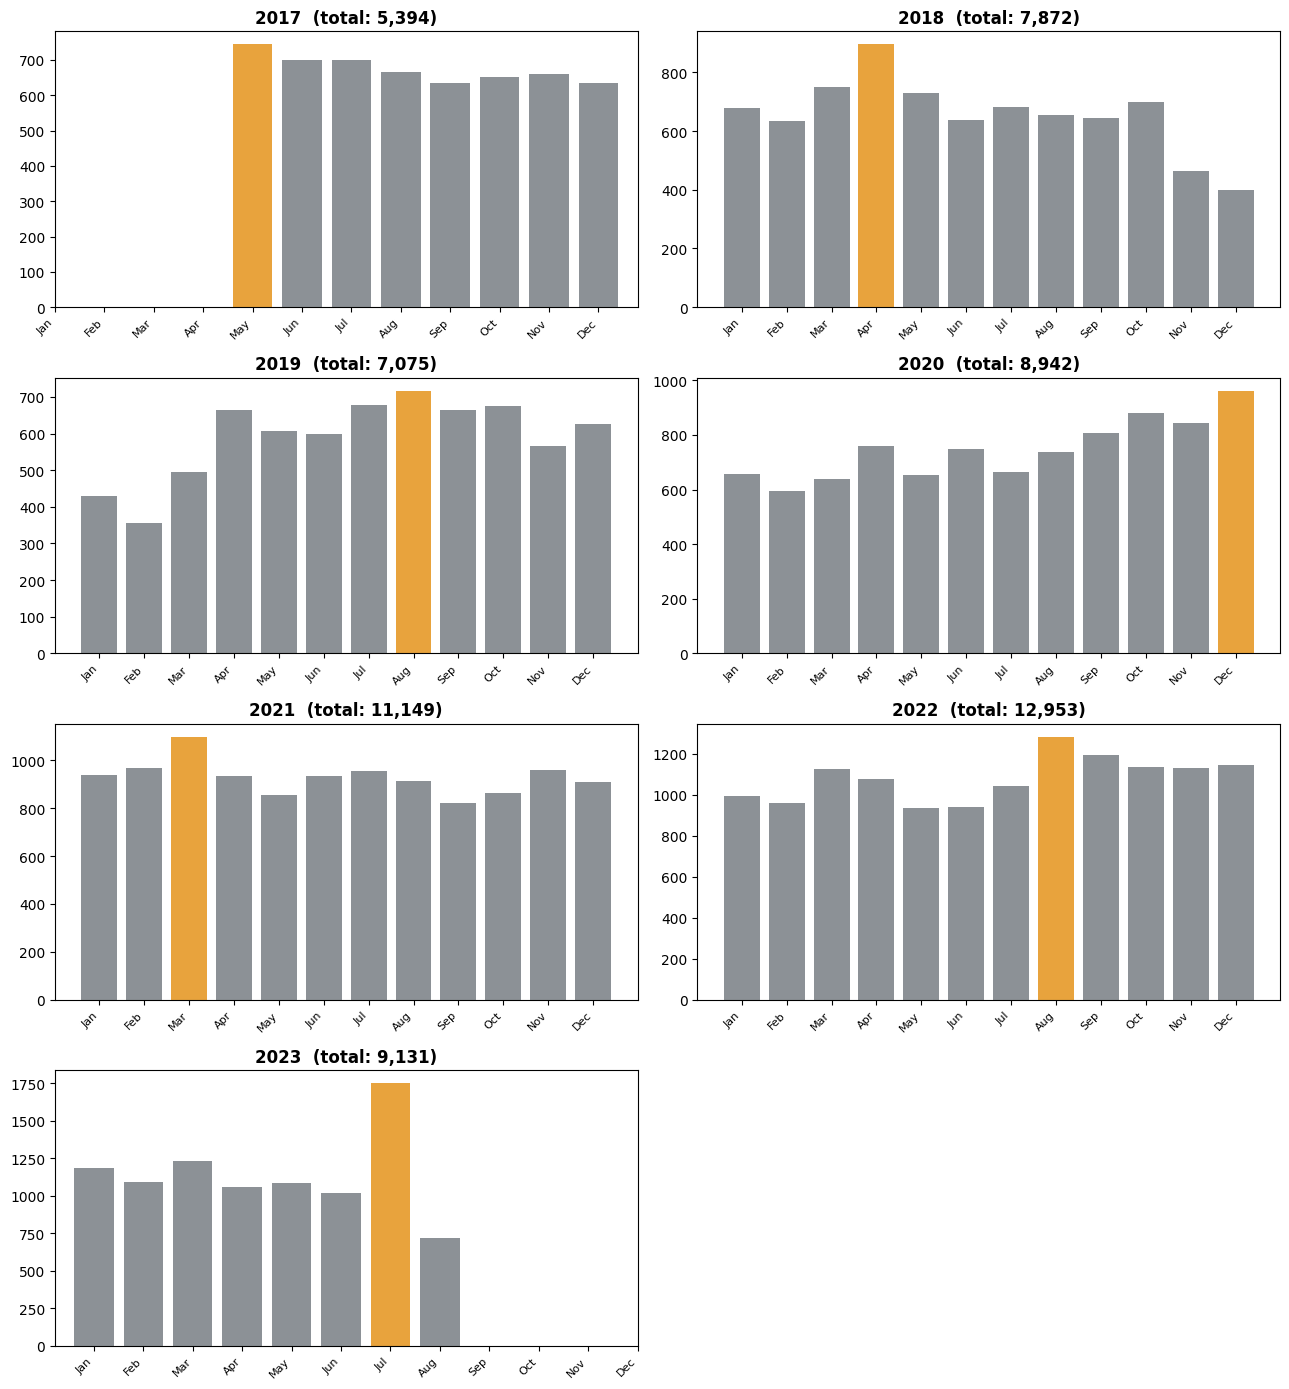

In [11]:
month_abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plot_data = seasonality_df.unstack(level="Month")["Complaint ID"]
colors = {"gold": "#E8A33D", "grey": "#8C9196"}

fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.flatten()

for i, year in enumerate(plot_data.index):
    ax = axes[i]
    values = plot_data.loc[year]
    max_val = values.max()  # skips NaN
    bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in values.values]
    ax.bar(range(1, 13), values.values, color=bar_colors)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_abbr, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{year}  (total: {values.sum():,.0f})', fontweight='bold')

for j in range(len(plot_data.index), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Do consumer complaints show any seasonal patterns?

</br>Answer:
</br>**There is no seasonal patterns shown.**

</br>While the chart shows July peaks at the total count for each months of every year. It is because number of complaints reaches the highest at July 2023, counting for a total of 1749, the highest amount received throughout 2017-2023.


Looking at each year's chart, each months does not consistently has the same high and low, for example, in 2018, the number of complaints decreases at the year's end, but it peaks at the end of 2020.

The chart also does not account for the missing months before May in 2017 and the missing months over September 2023, regardless, it does not peak on the same month roughly at each year.

</br> However, there is a steady increase in the number of complaints received each year, especially from 2020. But based on the dataset alone, it's not known the reason is as to why.

## Which products present the most complaints? What are its most common issues?

In [12]:
top_products = df["Product"].value_counts()
top_products

,count
Product,
Checking or savings account,24814
Credit card or prepaid card,16197
"Credit reporting, credit repair services, or other personal consumer reports",7710
Mortgage,6601
"Money transfer, virtual currency, or money service",3453
Debt collection,2736
Vehicle loan or lease,633
"Payday loan, title loan, or personal loan",333
Student loan,39


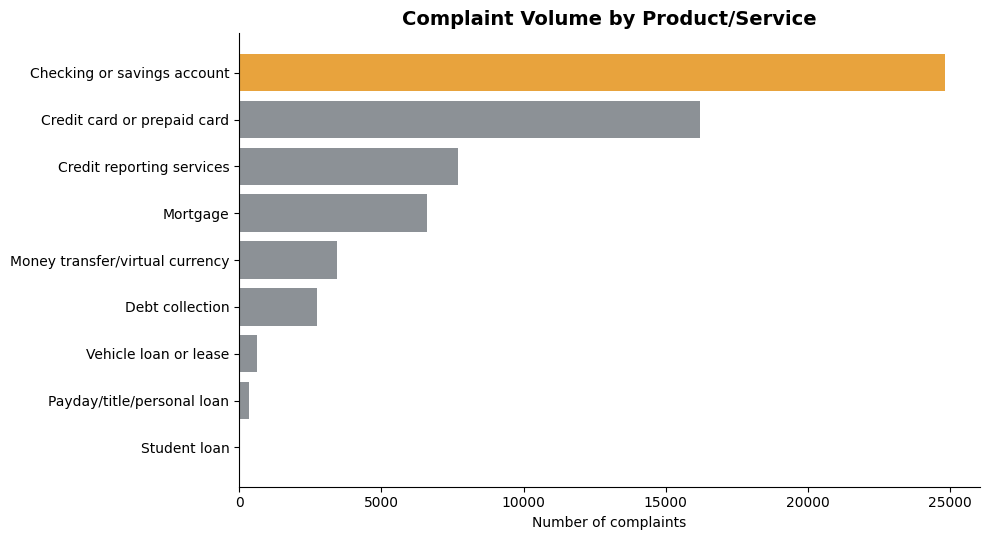

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {"gold": "#E8A33D", "grey": "#8C9196"}
top10 = top_products.head(10)

short_labels = (
    top10.index
    .str.replace("Credit reporting, credit repair services, or other personal consumer reports", "Credit reporting services")
    .str.replace("Money transfer, virtual currency, or money service", "Money transfer/virtual currency")
    .str.replace("Payday loan, title loan, or personal loan", "Payday/title/personal loan")
)

max_val = top10.max()
bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in top10.values]

ax.barh(short_labels[::-1], top10.values[::-1], color=bar_colors[::-1])
ax.set_title("Complaint Volume by Product/Service", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of complaints")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

In [14]:
top_product = top_products.idxmax()
top_subproducts = df[df['Product'] == top_product]['Sub-product'].value_counts()
top_subproducts

,count
Sub-product,
Checking account,20768
Other banking product or service,2568
Savings account,1239
CD (Certificate of Deposit),232


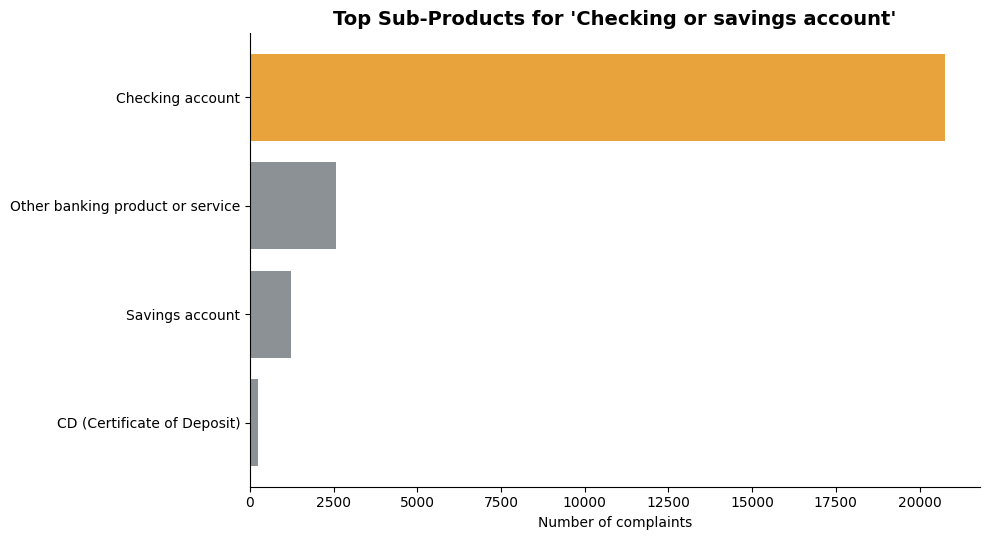

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {"gold": "#E8A33D", "grey": "#8C9196"}
top10 = top_subproducts.head(10)

max_val = top10.max()
bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in top10.values]

ax.barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1])
ax.set_title(f"Top Sub-Products for '{top_product}'", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of complaints")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

In [16]:
top_issues = df[df["Product"] == top_product]["Issue"].value_counts()
top_issues

,count
Issue,
Managing an account,15109
Closing an account,2953
Opening an account,2725
Problem with a lender or other company charging your account,2493
Problem caused by your funds being low,1330
Incorrect information on your report,129
Problem with a credit reporting company's investigation into an existing problem,20
Problem with fraud alerts or security freezes,17
Credit monitoring or identity theft protection services,17


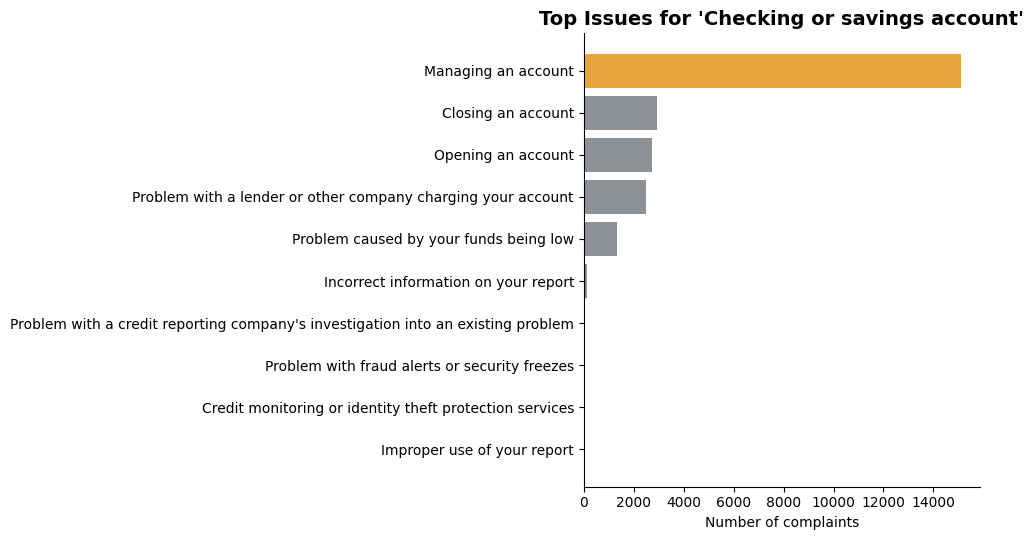

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {"gold": "#E8A33D", "grey": "#8C9196"}
top10 = top_issues.head(10)

max_val = top10.max()
bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in top10.values]

ax.barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1])
ax.set_title(f"Top Issues for '{top_product}'", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of complaints")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

In [18]:
top_issue = df[df['Product'] == top_product]['Issue'].value_counts().idxmax()
sub_issues = df[df['Issue'] == top_issue]['Sub-issue'].value_counts()
sub_issues

,count
Sub-issue,
Deposits and withdrawals,5596
Problem using a debit or ATM card,3356
Banking errors,1484
Funds not handled or disbursed as instructed,1423
Fee problem,1127
Problem making or receiving payments,824
Problem accessing account,623
Cashing a check,605
Deposits or withdrawals,66


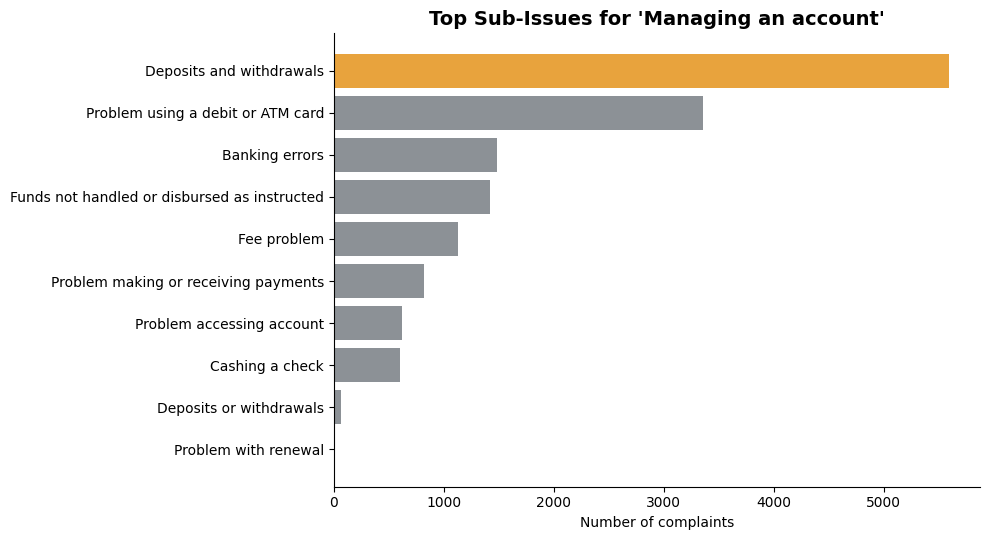

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {"gold": "#E8A33D", "grey": "#8C9196"}
top10 = sub_issues.head(10)

max_val = top10.max()
bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in top10.values]

ax.barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1])
ax.set_title(f"Top Sub-Issues for '{top_issue}'", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of complaints")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close()

Which products present the most complaints? What are its most common issues?

</br>Answer:
</br>The products that present the most complaints is **Checking or Saving account**, specifically on **Checking account**.

The most common issue based on the most complained product is **Managing an account**, with its common sub issue of **Deposit and withdrawals**.

## How are complaints typically resolved?

In [20]:
resolution = df["Company response to consumer"].value_counts()
resolution

,count
Company response to consumer,
Closed with explanation,41044
Closed with monetary relief,14697
Closed with non-monetary relief,5273
In progress,1494
Closed,8


In [25]:
top10_products = top_products.head(10).index
resolution_by_product = (
    df[df['Product'].isin(top10_products)]
    .groupby(['Product', 'Company response to consumer'])
    .size()
    .unstack(fill_value=0)
)
resolution_by_product = resolution_by_product.loc[top10_products]
resolution_by_product['Total'] = resolution_by_product.sum(axis=1)
resolution_by_product

Company response to consumer,Closed,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,In progress,Total
Product,,,,,,
Checking or savings account,0,14836,8027,1241,710,24814
Credit card or prepaid card,5,9361,4798,1621,412,16197
"Credit reporting, credit repair services, or other personal consumer reports",2,6067,273,1178,190,7710
Mortgage,1,4928,750,876,46,6601
"Money transfer, virtual currency, or money service",0,2709,634,41,69,3453
Debt collection,0,2367,111,209,49,2736
Vehicle loan or lease,0,477,61,79,16,633
"Payday loan, title loan, or personal loan",0,262,42,27,2,333
Student loan,0,37,1,1,0,39


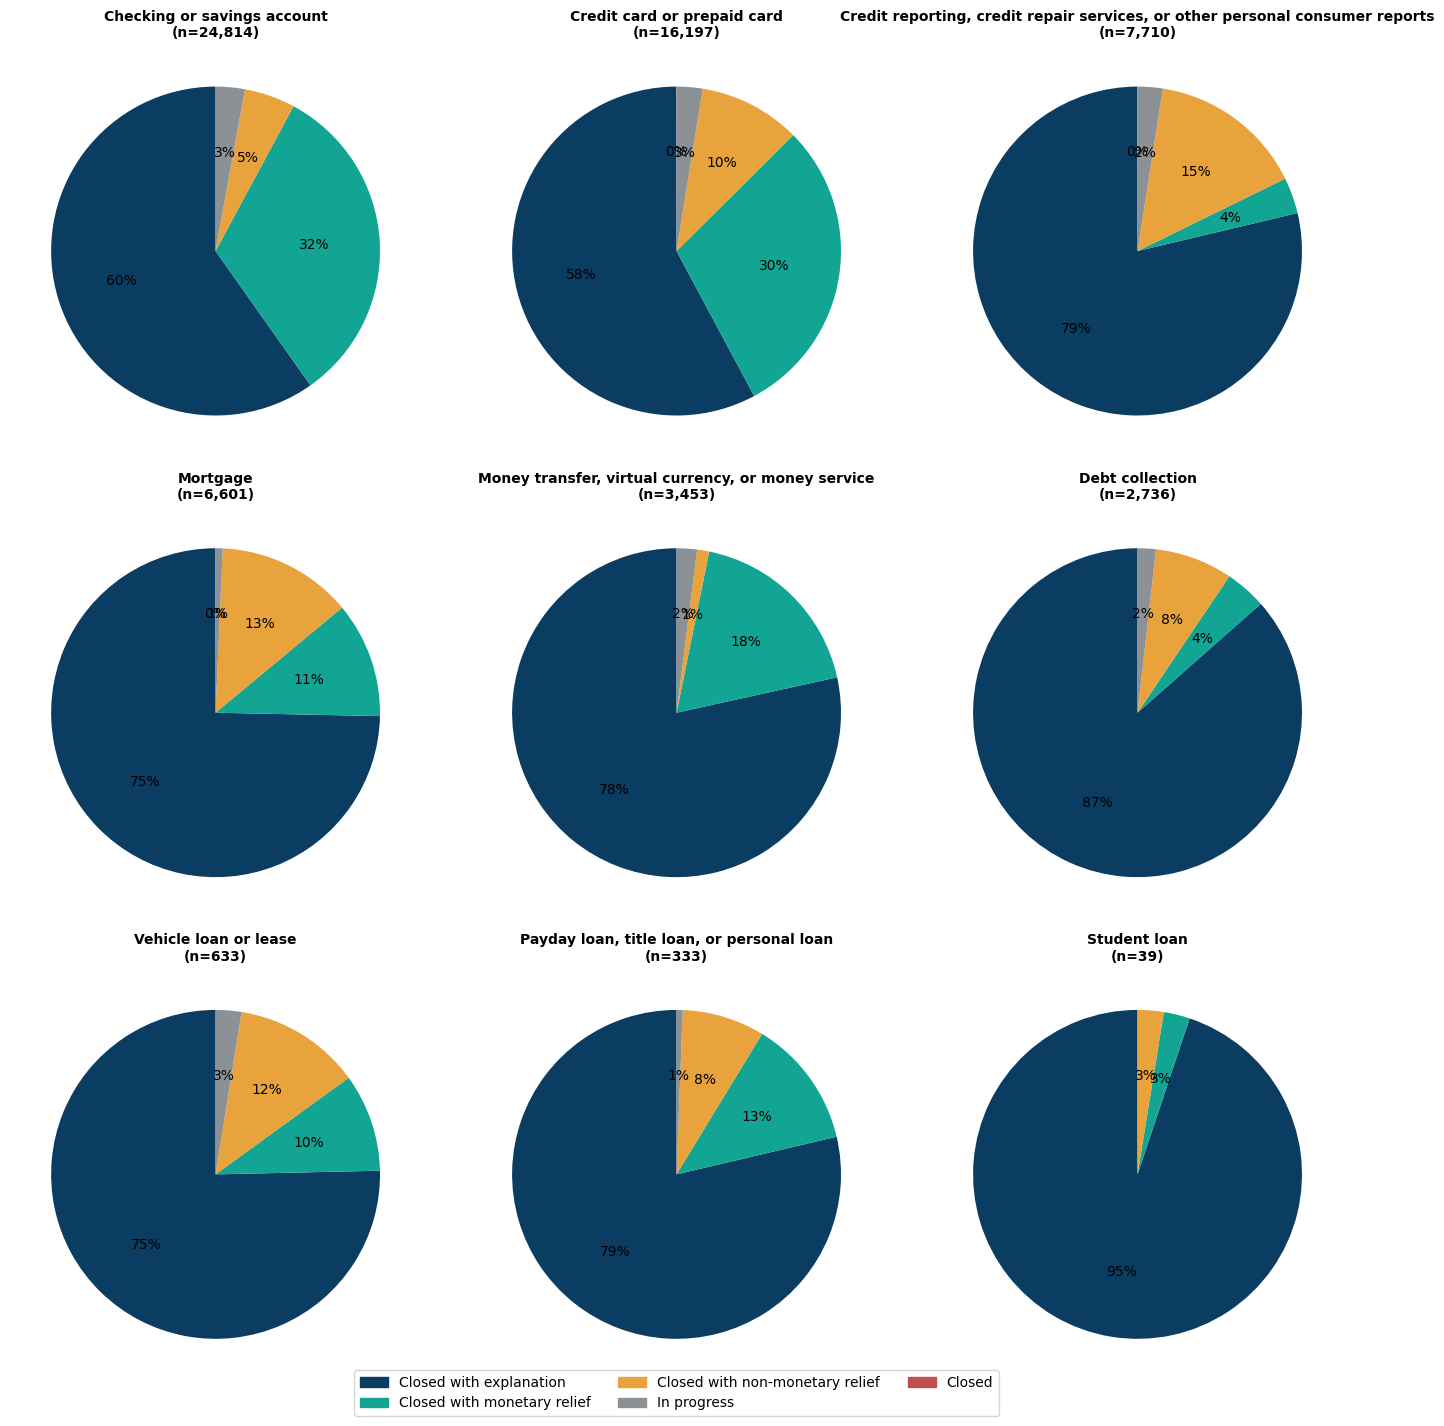

In [26]:
resolution_by_product = (
    df[df['Product'].isin(top10_products)]
    .groupby(['Product', 'Company response to consumer'])
    .size()
    .unstack(fill_value=0)
)
resolution_by_product = resolution_by_product.loc[top10_products]

colors_map = {
    'Closed with explanation': '#0B3D62',
    'Closed with monetary relief': '#12A594',
    'Closed with non-monetary relief': '#E8A33D',
    'In progress': '#8C9196',
    'Closed': '#C0504D',
}

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, product in enumerate(resolution_by_product.index):
    ax = axes[i]
    row = resolution_by_product.loc[product]
    row = row[row > 0]  # drop categories this product never uses
    pie_colors = [colors_map.get(cat, '#333333') for cat in row.index]
    ax.pie(row.values, autopct='%1.0f%%', colors=pie_colors, startangle=90)
    ax.set_title(f"{product}\n(n={row.sum():,})", fontsize=10, fontweight='bold')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors_map.values()]
fig.legend(handles, colors_map.keys(), loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

In [27]:
top_issue = df[df['Product'] == top_product]['Issue'].value_counts().idxmax()

resolution_top_issue = df[df['Issue'] == top_issue]['Company response to consumer'].value_counts()
resolution_top_issue = resolution_top_issue[resolution_top_issue > 0]  # drop empty categories
resolution_top_issue

,count
Company response to consumer,
Closed with explanation,9048
Closed with monetary relief,5206
Closed with non-monetary relief,475
In progress,380


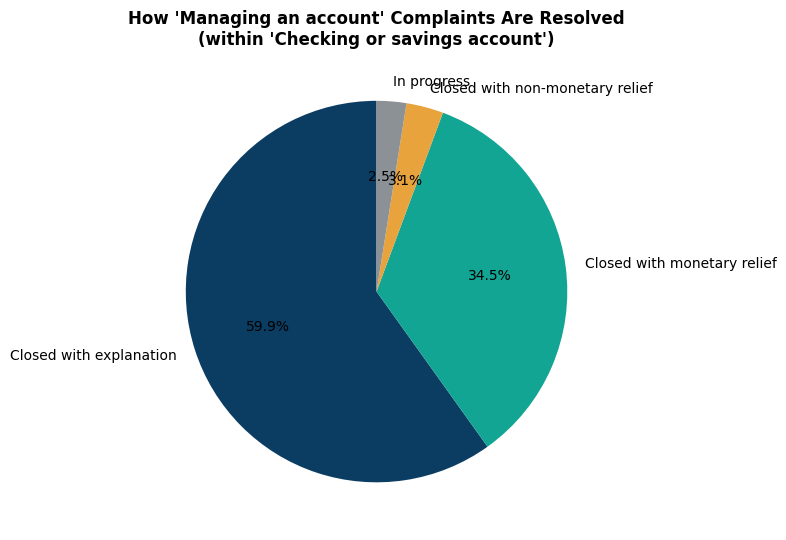

In [28]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.pie(resolution_top_issue.values, labels=resolution_top_issue.index, autopct='%1.1f%%',
       colors=['#0B3D62','#12A594','#E8A33D','#8C9196'], startangle=90)
ax.set_title(f"How '{top_issue}' Complaints Are Resolved\n(within '{top_product}')", fontweight='bold')
plt.tight_layout()
plt.show()

How are complaints typically resolved?

</br>Answer:
</br>Complaints are typically resolved with an explanation, the majority of resolution from all of the complaints issued from every products are resolved with an explanation, followed by resolved with monetary relief, then resolved without monetary relief, then some is still in progress, then closed without explanation which is mostly issued from credit card or prepaid card.

## Can you learn anything from the complaints with untimely responses?

In [29]:
timely_counts = df["Timely response?"].value_counts(dropna=False)
timely_counts

,count
Timely response?,
Yes,58619
No,2403
NaN,1494


In [30]:
df['Timely response missing?'] = df['Timely response?'].isna()

no_response_yet = pd.crosstab(df['Company response to consumer'], df['Timely response missing?'])
no_response_yet.columns = ['Has a value', 'Is NaN']
no_response_yet

,Has a value,Is NaN
Company response to consumer,,
Closed,8,0
Closed with explanation,41044,0
Closed with monetary relief,14697,0
Closed with non-monetary relief,5273,0
In progress,0,1494


Based on this dataset, timely response refers to whether the company gives a response within a set of deadline, "Yes" means the company gives a response within the deadline, and "No" means the company gives a response after the deadline, while "Nan" means it's still in progress.

In [31]:
untimely = df[df["Timely response?"] == "No"]
untimely_year = untimely["Date submitted"].dt.year.value_counts().sort_index()
untimely_year

,count
Date submitted,
2017,9
2018,12
2019,7
2020,62
2021,1224
2022,567
2023,522


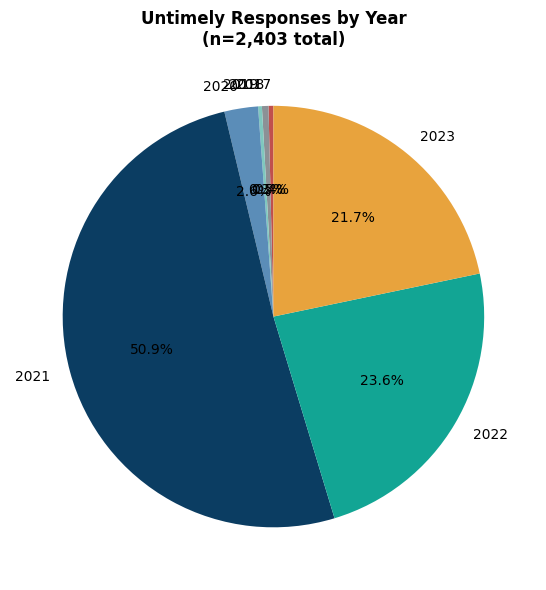

In [32]:
colors_map = {
    2017: '#C0504D',
    2018: '#8C9196',
    2019: '#7FC8BE',
    2020: '#5B8DB8',
    2021: '#0B3D62',
    2022: '#12A594',
    2023: '#E8A33D'
}
colors_list = [colors_map[year] for year in sorted(untimely_year.index)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    untimely_year.values,
    labels=untimely_year.index,
    autopct='%1.1f%%',
    colors=colors_list[:len(untimely_year)],
    startangle=90,
)
ax.set_title(f"Untimely Responses by Year\n(n={untimely_year.sum():,} total)", fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
untimely_product = untimely["Product"].value_counts()
untimely_product

,count
Product,
Checking or savings account,867
Credit card or prepaid card,689
"Credit reporting, credit repair services, or other personal consumer reports",475
Debt collection,173
"Money transfer, virtual currency, or money service",140
Vehicle loan or lease,33
Mortgage,16
"Payday loan, title loan, or personal loan",10


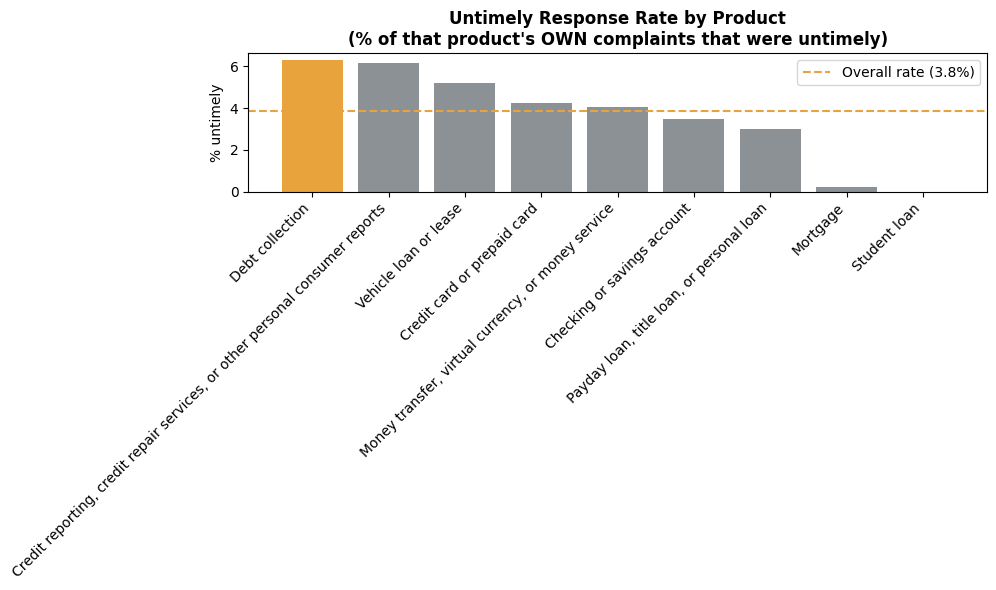

In [38]:
untimely_product = untimely["Product"].value_counts()
total_product = df["Product"].value_counts()

# reindex + fillna(0): products with ZERO untimely complaints (e.g. Student loan) get 0%, not NaN
untimely_rate_by_product = (
    untimely_product.reindex(total_product.index, fill_value=0) / total_product * 100
).round(2).sort_values(ascending=False)

colors = {"gold": "#E8A33D", "grey": "#8C9196"}
max_val = untimely_rate_by_product.max()
bar_colors = [colors["gold"] if v == max_val else colors["grey"] for v in untimely_rate_by_product.values]
overall_rate = (len(untimely) / len(df)) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(untimely_rate_by_product.index, untimely_rate_by_product.values, color=bar_colors)
ax.axhline(overall_rate, color=colors["gold"], linestyle='--', label=f'Overall rate ({overall_rate:.1f}%)')
ax.set_title("Untimely Response Rate by Product\n(% of that product's OWN complaints that were untimely)", fontweight='bold')
ax.set_ylabel('% untimely')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
timely_rate_by_channel = (
  df.groupby("Submitted via")["Timely response?"]
  .apply(lambda x: (x == "Yes").mean() * 100)
  .round(1)
)
timely_rate_by_channel

,Timely response?
Submitted via,
Email,100.0
Fax,99.6
Phone,93.5
Postal mail,97.3
Referral,96.9
Web,92.9
Web Referral,87.8


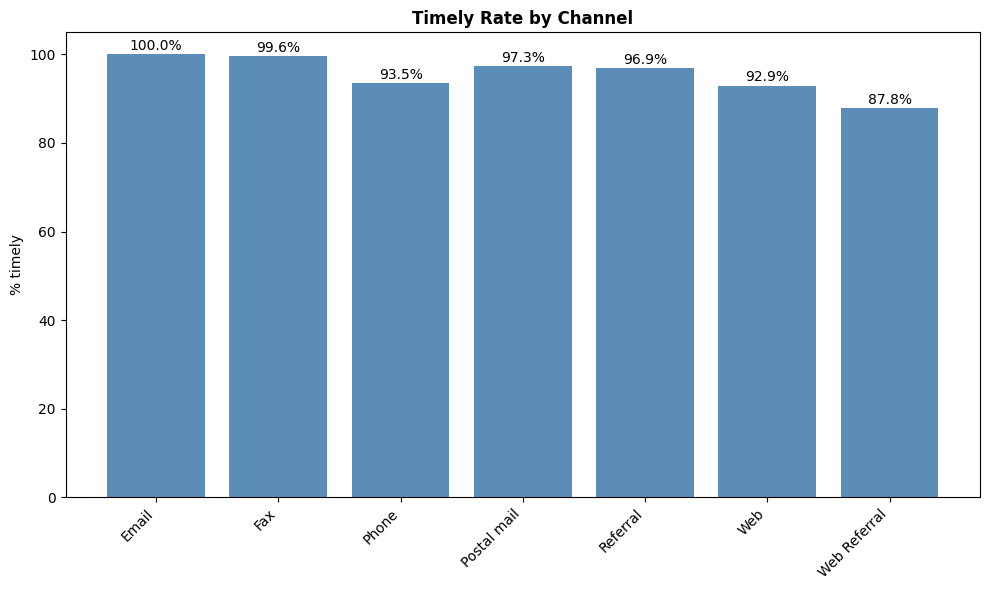

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(timely_rate_by_channel.index, timely_rate_by_channel.values, color='#5B8DB8')
ax.set_ylim(0, 105)
ax.set_ylabel('% timely')
ax.set_title('Timely Rate by Channel', fontweight='bold')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(timely_rate_by_channel.values):
    ax.text(i, v + 1, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

In [44]:
from scipy.stats import chi2_contingency

# Exclude NaN
df_known = df.dropna(subset=['Timely response?'])

contingency = pd.crosstab(df_known['Submitted via'], df_known['Timely response?'])
print(contingency)

# Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.2e}")


# Cramer's V: effect size (HOW strong the relationship actually is)
n = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = (chi2 / (n * min_dim)) ** 0.5

print(f"Cramer's V (effect size): {cramers_v:.3f}")
# print("Guide: <0.1 negligible | 0.1-0.3 weak | 0.3-0.5 moderate | >0.5 strong")

Timely response?    No    Yes
Submitted via                
Email                0      2
Fax                  1    232
Phone              172   4380
Postal mail         28   1282
Referral           281  10434
Web               1917  42210
Web Referral         4     79
Chi-square statistic: 87.64
Degrees of freedom:   6
p-value:              9.35e-17
Cramer's V (effect size): 0.038


Can you learn anything from the complaints with untimely responses?

</br>Answer:
</br>The number of untimely response is a small percentages in the whole dataset, with 2021 being the year with the highest amount of untimely responses, and the next years afterward declines significantly.

Most of the untimely respond based on the products is from Checking or savings account, followed by credit card complaints, which is propotional to their overall volume. However, based on the percentages of that products complaints that were untimely, the majority of it is from debt collection, while the untimely response for checking or saving accounts is lower than the overall rate.

Based on where the complaints were submitted, Web submission is the most used one, yet also the least timely. However, it does not meant it's a guarantee that submitting complaints from other channel will receive a more timely response, so, there is no significant effect between the submission channel and the timely response given.